In [183]:
#librerias
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import pandas as pd

In [184]:
#crea la carpeta de archivo original y resultado
og = pathlib.Path.cwd() / "Archivos" 
og.mkdir(exist_ok=True) #evita errores en caso de que la carpeta ya exista
res = pathlib.Path.cwd() / "Resultados"
res.mkdir(exist_ok = True)
og, res

(PosixPath('/Users/cata/Desktop/Tarea 3/Archivos'),
 PosixPath('/Users/cata/Desktop/Tarea 3/Resultados'))

In [185]:
#lectura del espectro con genfromtxt
archivo = og / "66-25-1-IR.jdx" #molecula usada: hexanal
data_np = np.genfromtxt(archivo, skip_header=24, skip_footer=1, dtype=float, filling_values="0")
n, a = [], [] #numero de onda, absorbancia

#importante: hay muchos valores de y para un valor de x!
#por lo tanto, deben agruparse estos valores para poder tenerlos en un dataframe (2x2)
#como se tiene:
##XYDATA=(X++(Y..Y))
##DELTAX=4.0
#para un valor de x, cada 4 cm^-1 se tienen valores de y
#se realiza el agrupamiento para cada fila del archivo:
for row in data_np:
    x0 = row[0]          # X inicial
    y = row[1:]          # todos los Y de la fila
    x = x0 + np.arange(len(y)) * 4
    n.extend(x)
    a.extend(y)
#se tiene que
l = (10**4)/np.array(n) #1 cm = 10^4 µm; se convierte inmediatamente la lista a array para poder operar sobre este
print(f"""Longitud de Onda (µm): {l}
Absorbancia: {a}""")

Longitud de Onda (µm): [22.22222222 22.02643172 21.83406114 21.64502165 21.45922747 21.27659574
 21.09704641 20.92050209 20.74688797 20.57613169 20.40816327 20.24291498
 20.08032129 19.92031873 19.76284585 19.60784314 19.45525292 19.30501931
 19.15708812 19.01140684 18.86792453 18.72659176 18.58736059 18.4501845
 18.31501832 18.18181818 18.05054152 17.92114695 17.79359431 17.66784452
 17.54385965 17.42160279 17.30103806 17.18213058 17.06484642 16.94915254
 16.83501684 16.72240803 16.61129568 16.50165017 16.39344262 16.28664495
 16.18122977 16.07717042 15.97444089 15.87301587 15.77287066 15.67398119
 15.57632399 15.47987616 15.38461538 15.29051988 15.19756839 15.10574018
 15.01501502 14.92537313 14.83679525 14.74926254 14.6627566  14.57725948
 14.49275362 14.4092219  14.32664756 14.24501425 14.16430595 14.08450704
 14.00560224 13.9275766  13.85041551 13.77410468 13.69863014 13.6239782
 13.5501355  13.47708895 13.40482574 13.33333333 13.26259947 13.19261214
 13.12335958 13.05483029 12.98

    Longitud  Absorbancia
0  22.222222        105.0
1  22.026432        129.0
2  21.834061        168.0
3  21.645022        115.0
4  21.459227         72.0
     Longitud  Absorbancia
865  2.557545         68.0
866  2.554931         70.0
867  2.552323         95.0
868  2.549720         40.0
869  2.547122         26.0
Longitud de Onda con la Máxima Absorbancia: 3.3990 µm
Absorbancia Máxima: 10000.0000
Ancho de banda: 2.4224


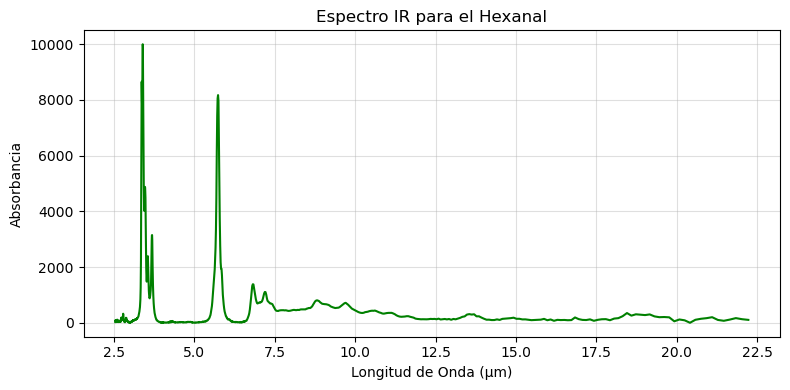

['Longitud Máx \t Absorbancia \n', '    3.3990 \t \t 10000.0000 \n', 'Ancho de Banda \t Absorbancia \n', '    2.4224']


In [14]:
#conversión a dataframe
df = pd.DataFrame({"Longitud": l, "Absorbancia": np.array(a)})
print(f"""{df.head()}
{df.tail()}""")
##maxima absorbancia y ancho de la banda
longitudmax = df.loc[df["Absorbancia"].idxmax(), "Longitud"]
absmax = df.loc[df["Absorbancia"].idxmax(), "Absorbancia"]
print(f"""Longitud de Onda con la Máxima Absorbancia: {longitudmax:.4f} µm
Absorbancia Máxima: {absmax:.4f}""")
#ancho de banda: a la mitad de la absorbancia máxima
mitadmax = absmax / 2
puntos = df["Absorbancia"] >= mitadmax
banda = df[puntos] #nuevo df que contiene únicamente los puntos que cumplen con la condición
fwhm = ancho_banda = banda["Longitud"].max() - banda["Longitud"].min() #fwhm = punto max - punto min
print(f"Ancho de banda: {fwhm:.4f}")
#gráfico
plt.figure(figsize=(8, 4))
plt.plot(df["Longitud"], df["Absorbancia"], "g-")
plt.xlabel("Longitud de Onda (µm)")
plt.ylabel("Absorbancia")
plt.title("Espectro IR para el Hexanal")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.savefig( res / "hexanal.png", dpi=300)
plt.show()
#escritura en la carpeta de resultados:
result = res / "resultados_absorbancia.txt"
with result.open("w") as f:
    f.write(f"Longitud Máx \t Absorbancia \n")
    f.write(f"{longitudmax:10.4f} \t \t {absmax:10.4f} \n")
    f.write(f"Ancho de Banda \t Absorbancia \n")
    f.write(f"{fwhm:10.4f}")
with result.open("r") as f:
    print(f.readlines())